<a href="https://colab.research.google.com/github/nandah4/PCVK_04_26/blob/main/Pertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
from skimage import io
import random

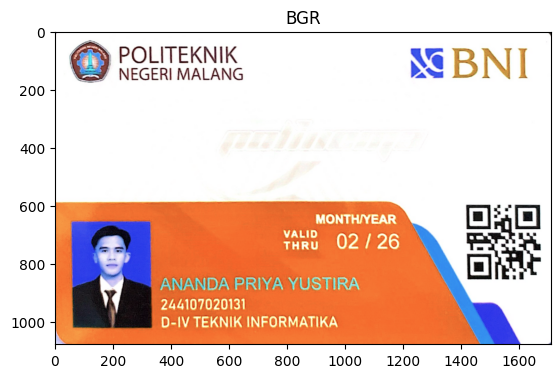

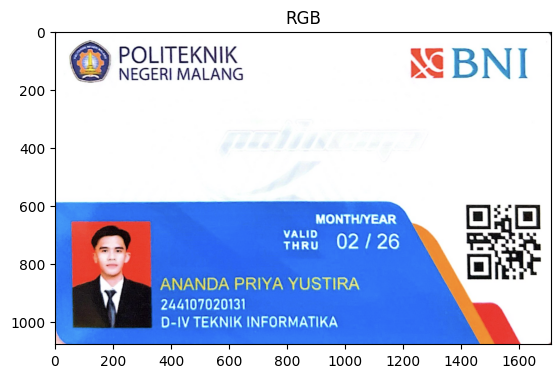

<function matplotlib.pyplot.show(close=None, block=None)>

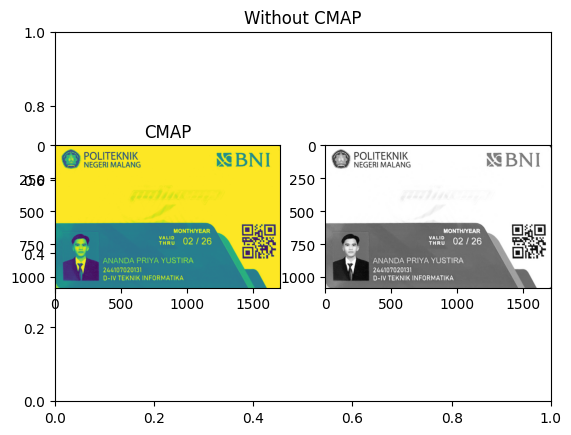

In [6]:


# 2. Menampilkan Gambar

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# The way to upload a file using pop up
# from google.colab import files
# uploaded = files.upload()

image = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png')
# cv2_imshow(image)

# BGR color format
image_BGR = image
plt.title('BGR')
plt.imshow(image_BGR)
plt.show()

# show with RGB format
plt.title('RGB')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

# Grayscale

image_grayscale = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png', cv2.IMREAD_GRAYSCALE)

plt.title('Without CMAP')
plt.subplot(1, 2, 1)
plt.imshow(image_grayscale)

plt.title('CMAP')
plt.subplot(1, 2, 2)
plt.imshow(image_grayscale, cmap="gray")

plt.show

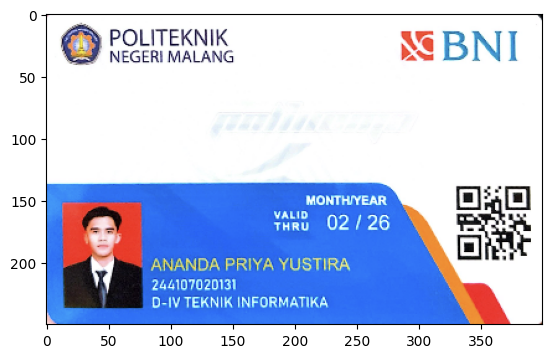

In [7]:
# 4. Resizing
image = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png')
img_RGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_RGB_small = cv2.resize(img_RGB, (400, 250))
plt.imshow(img_RGB_small)


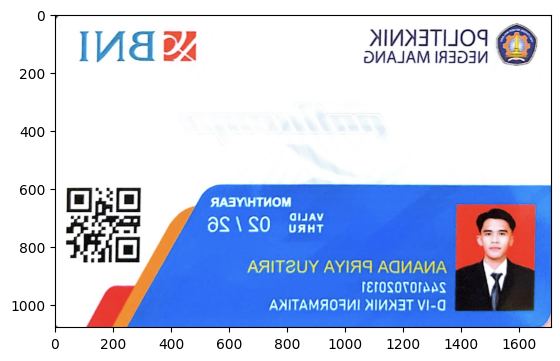

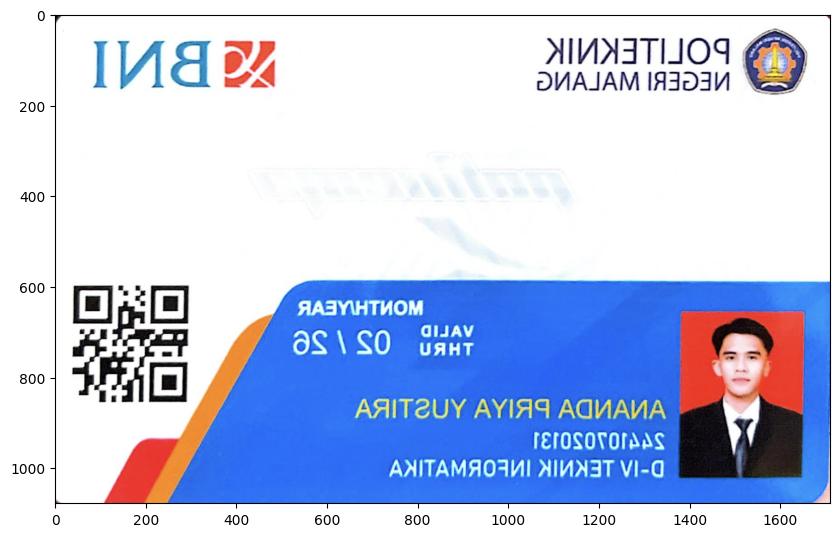

In [8]:
# 5. Flipping
img_flip = cv2.flip(img_RGB, 1)
plt.imshow(img_flip)

# Menampilkan canvas lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(img_flip)

plt.show()

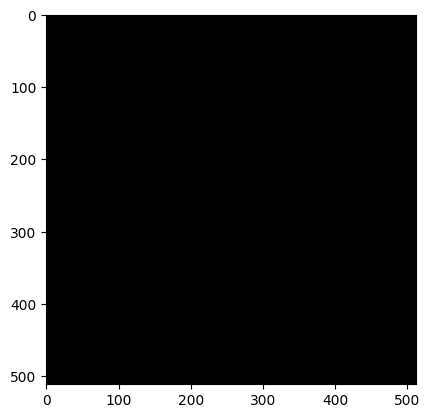

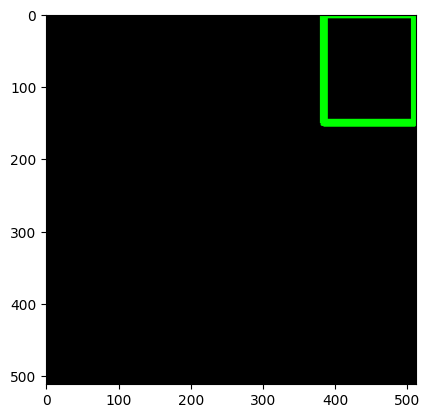

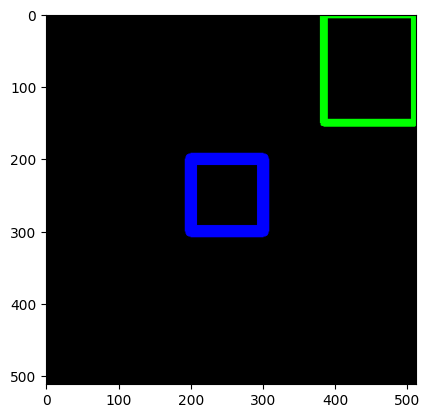

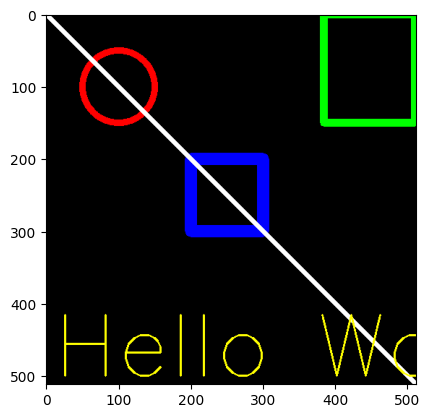

In [9]:
# Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

black_img = np.zeros(shape=(512,512,3), dtype=np.int16)
plt.imshow(black_img)

plt.show()

#Menambahkan bentuk persegi panjang sesuai koordinat pt1 dan pt2
cv2.rectangle(black_img, pt1=(384,0), pt2=(510, 150), color=(0, 255, 0), thickness=10)
plt.imshow (black_img)

plt.show()


cv2.rectangle(black_img, pt1=(200,200), pt2=(300, 300), color=(0, 0, 255), thickness=15)
plt.imshow (black_img)

plt.show()

# Rounded
cv2.circle(black_img, center=(100,100), radius=50, color=(255, 0, 0), thickness=8)

# Line
cv2.line(black_img, pt1=(0,0), pt2=(512, 512), color=(255, 255, 255), thickness=5)

# Font
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text="Hello World", org=(10, 500), fontFace=font, fontScale=4, color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)
plt.imshow (black_img)

plt.show()

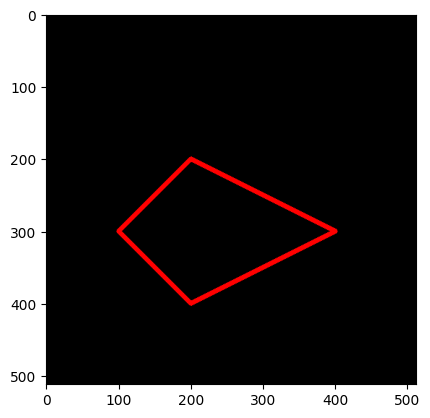

In [10]:
# Black Image 2
black_img_2 = np.zeros(shape=(512,512,3), dtype=np.int32)

vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)

pts = vertices.reshape(
    (-1, 1, 2)
)  # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B

cv2.polylines(black_img_2, [pts], isClosed=True, color=(255, 0, 0), thickness=5)
plt.imshow(black_img_2)

plt.show()

<ol style="font-size: 14px;">
  <li>
    <strong>Apakah perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib?</strong>
    <ul>
      <li><strong>Format Kanal Warna (BGR vs RGB):</strong> OpenCV membaca citra dalam format warna BGR secara default. Jika ditampilkan menggunakan <code>matplotlib</code> (<code>plt.imshow()</code>) tanpa konversi warna, gambar akan terlihat dengan warna yang tertukar (misalnya area merah menjadi biru). Sebaliknya, jika ditampilkan tanpa <code>matplotlib</code> (misalnya menggunakan <code>cv2_imshow</code>), gambar ditampilkan langsung dalam urutan warna yang sesuai.</li>
      <li><strong>Fitur Sumbu dan Interaktivitas:</strong> Menampilkan gambar dengan <code>matplotlib</code> menyertakan sumbu koordinat piksel (sumbu X dan Y), judul figure, serta skala gambar. Tanpa <code>matplotlib</code> (menggunakan <code>cv2_imshow</code>), gambar ditampilkan sebagai citra murni tanpa sumbu koordinat.</li>
    </ul>
  </li>
  
  <li>
    <strong>Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data int16 dan int32?</strong>
    <ul>
      <li><strong>Perbedaan Alokasi Memori:</strong> Tipe data <code>int16</code> menggunakan 16 bit (2 byte) per elemen/piksel, sedangkan <code>int32</code> menggunakan 32 bit (4 byte) per elemen/piksel. Penggunaan <code>int32</code> memakan konsumsi memori (RAM) dua kali lebih besar dibanding <code>int16</code>.</li>
      <li><strong>Rentang Nilai (Range):</strong> <code>int16</code> menyimpan nilai dari -32,768 hingga 32,767, sedangkan <code>int32</code> menyimpan nilai dari -2,147,483,648 hingga 2,147,483,647.</li>
      <li><strong>Pengaruh pada Citra:</strong> Untuk citra standar 8-bit (nilai piksel 0–255), tipe data standar yang digunakan sebenarnya adalah <code>uint8</code>. Jika menggunakan <code>int16</code> atau <code>int32</code> untuk <em>black image</em> (berisi nilai 0), tampilan visualnya sama-sama berwarna hitam. Namun, jika dilakukan operasi aritmatika gambar atau plotting, <code>matplotlib</code> dan OpenCV dapat menginterpretasikan skala warna secara berbeda jika tipe datanya bukan <code>uint8</code> atau float, yang bisa menyebabkan gambar tidak muncul dengan benar (seperti terlihat serba putih atau bernilai anomali) sebelum di-cast kembali ke <code>uint8</code>.</li>
    </ul>
  </li>
  
  <li>
    <strong>Apakah kegunaan "google.colab.patches import cv2_imshow" pada potongan kode berikut?</strong>
    <ul>
      <li>Fungsi <code>cv2.imshow()</code> asli bawaan OpenCV menyebabkan crash / pembekuan (session crash) jika dijalankan di lingkungan Google Colab karena Colab tidak mendukung jendela GUI pop-up desktop.</li>
      <li>Modul <code>cv2_imshow</code> dari <code>google.colab.patches</code> disediakan khusus sebagai alternatif pengganti <code>cv2.imshow()</code> agar gambar dapat ditampilkan secara langsung (inline) di dalam cell output Google Colab tanpa menyebabkan crash.</li>
    </ul>
  </li>
  
  <li>
    <strong>Apakah kegunaan "skimage import io" pada potongan kode soal nomor 3?</strong>
    <ul>
      <li>Modul <code>io</code> dari library <code>skimage</code> (scikit-image) digunakan untuk menangani operasi Input/Output citra.</li>
      <li>Fungsi utamanya adalah membaca gambar (misalnya menggunakan <code>io.imread()</code>) baik dari penyimpanan lokal maupun langsung dari tautan/URL internet, serta menyimpan gambar (<code>io.imsave()</code>).</li>
    </ul>
  </li>
</ol>

**Tugas Praktikum D3**

 1. Mengubah ukuran tampilan dengan figsize
 Jawaban: Tidak Berubah. `figsize` pada Matplotlib hanya mengubah ukuran tampilan figure pada layar notebook,s edangkan resolusi asli matriks/array pixel citra (image.shape) tetap sama.

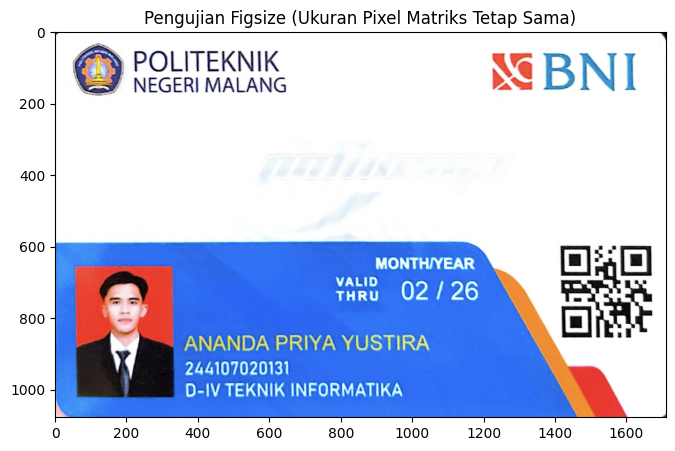

Ukuran Matriks Pixel Asli (Height, Width, Channel): (1078, 1710, 3)


In [11]:

image_rgb = io.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png')
plt.figure(figsize=(10, 5))
plt.imshow(image_rgb)
plt.title("Pengujian Figsize (Ukuran Pixel Matriks Tetap Sama)")
plt.show()
print("Ukuran Matriks Pixel Asli (Height, Width, Channel):", image.shape)




 2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja

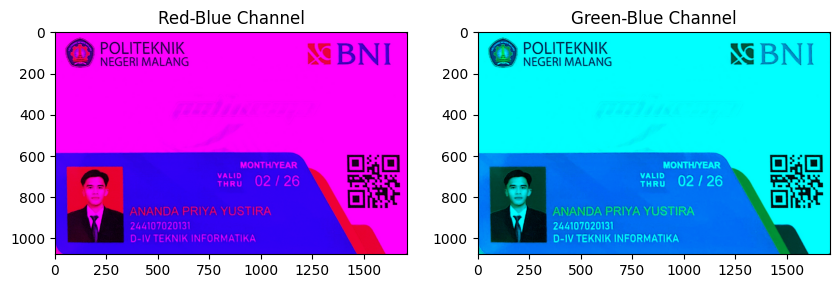

In [12]:
# Channel Red-Blue (Set channel Green / Index 1 menjadi 0)
img_rb = image_rgb.copy()
img_rb[:, :, 1] = 0

# Channel Green-Blue (Set channel Red / Index 0 menjadi 0)
img_gb = image_rgb.copy()
img_gb[:, :, 0] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title("Red-Blue Channel")

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title("Green-Blue Channel")
plt.show()

3. Tampilkan image baris ke 20-115, kolom 25-120

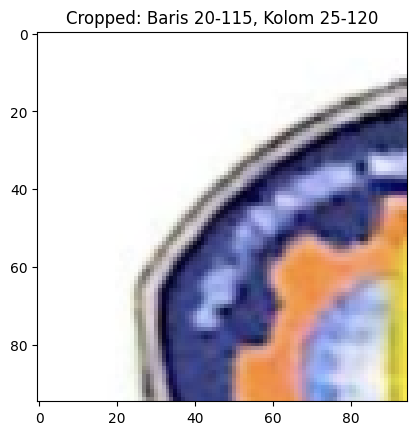

In [13]:

img_crop_1 = image_rgb[20:115, 25:120]

plt.figure()
plt.imshow(img_crop_1)
plt.title("Cropped: Baris 20-115, Kolom 25-120")
plt.show()

4. Tampilkan image baris ke 5-30, semua kolom, channel Red saja

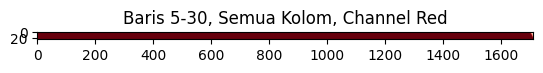

In [14]:

img_red_crop = image_rgb[5:30, :, 0]  # Channel Red pada RGB adalah Index 0

plt.figure()
plt.imshow(img_red_crop, cmap="Reds")
plt.title("Baris 5-30, Semua Kolom, Channel Red")
plt.show()

5. Buat 5 kotak berbagai ukuran dan warna acak dalam satu image

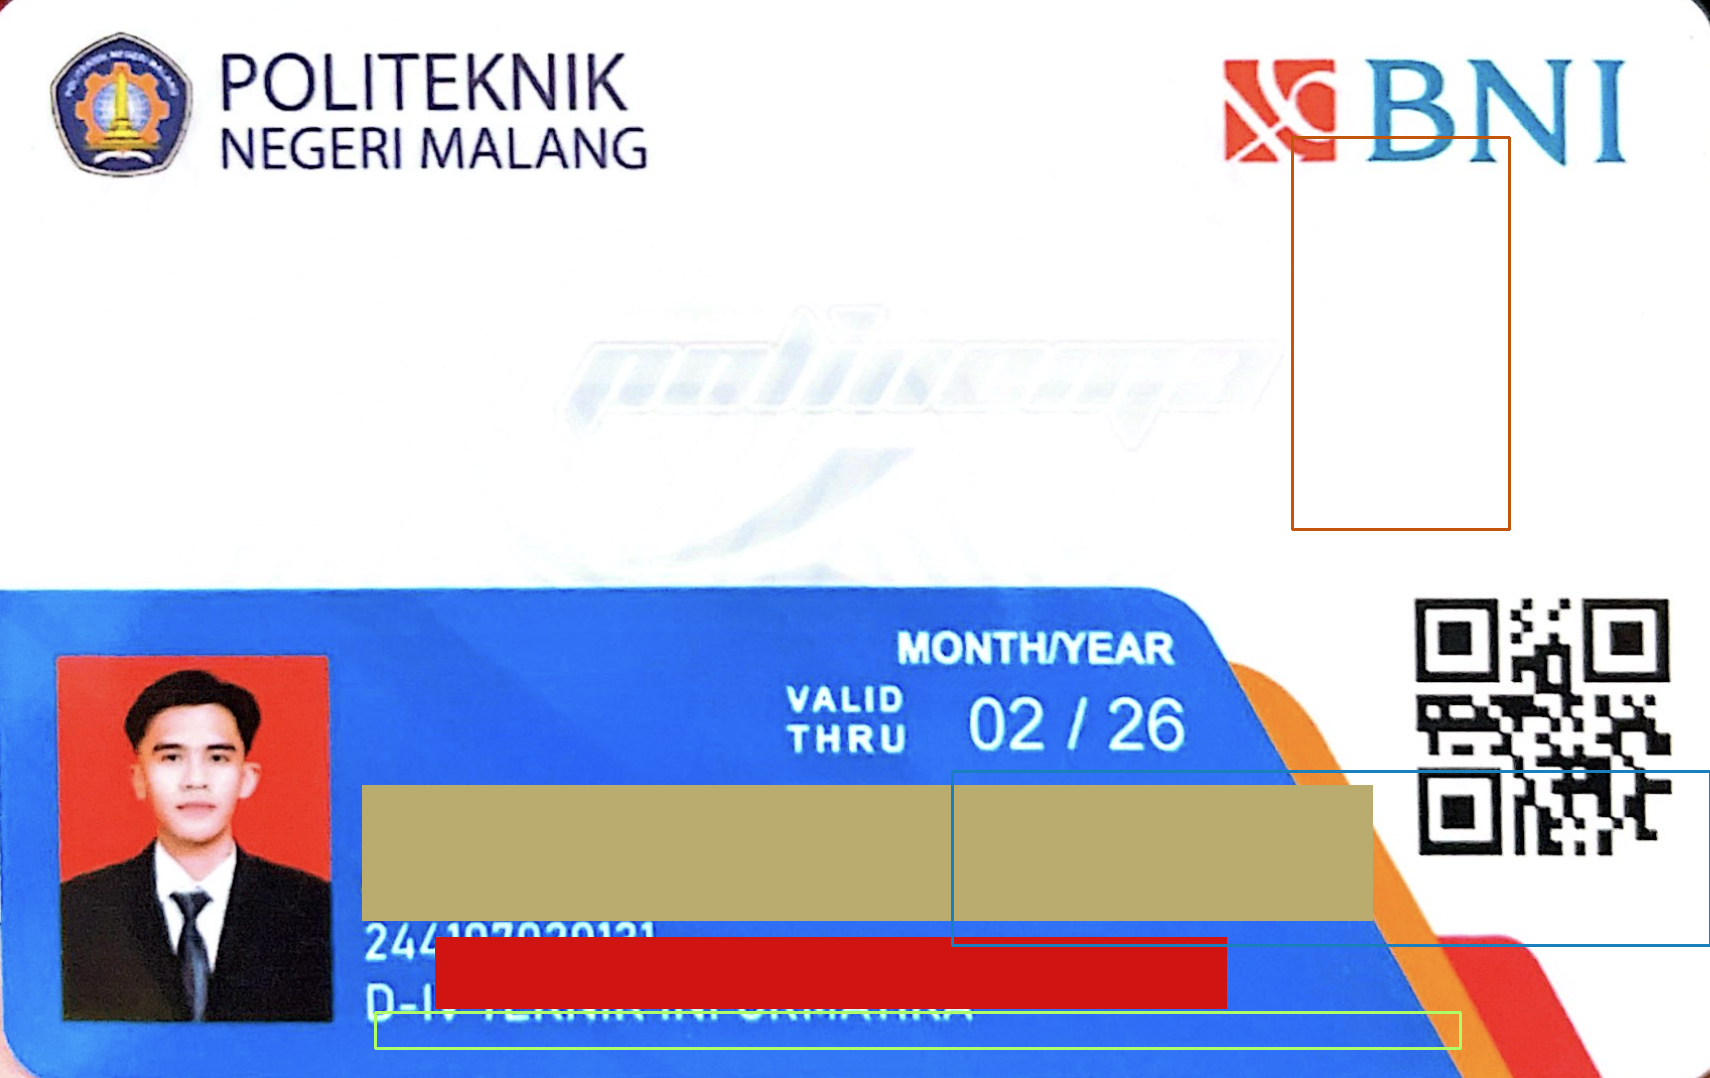

In [15]:

img_boxes = image.copy()  # Menggunakan format BGR bawaan OpenCV
h, w, _ = img_boxes.shape

for _ in range(5):
    x1, y1 = random.randint(0, w - 50), random.randint(0, h - 50)
    x2, y2 = random.randint(x1 + 20, w), random.randint(y1 + 20, h)
    color = (
        random.randint(0, 255),
        random.randint(0, 255),
        random.randint(0, 255),
    )
    thickness = random.choice([2, 3, -1])  # -1 jika ingin kotak terisi penuh
    cv2.rectangle(img_boxes, (x1, y1), (x2, y2), color, thickness)

cv2_imshow(img_boxes)

6. Tampilkan image dengan posisi terbalik

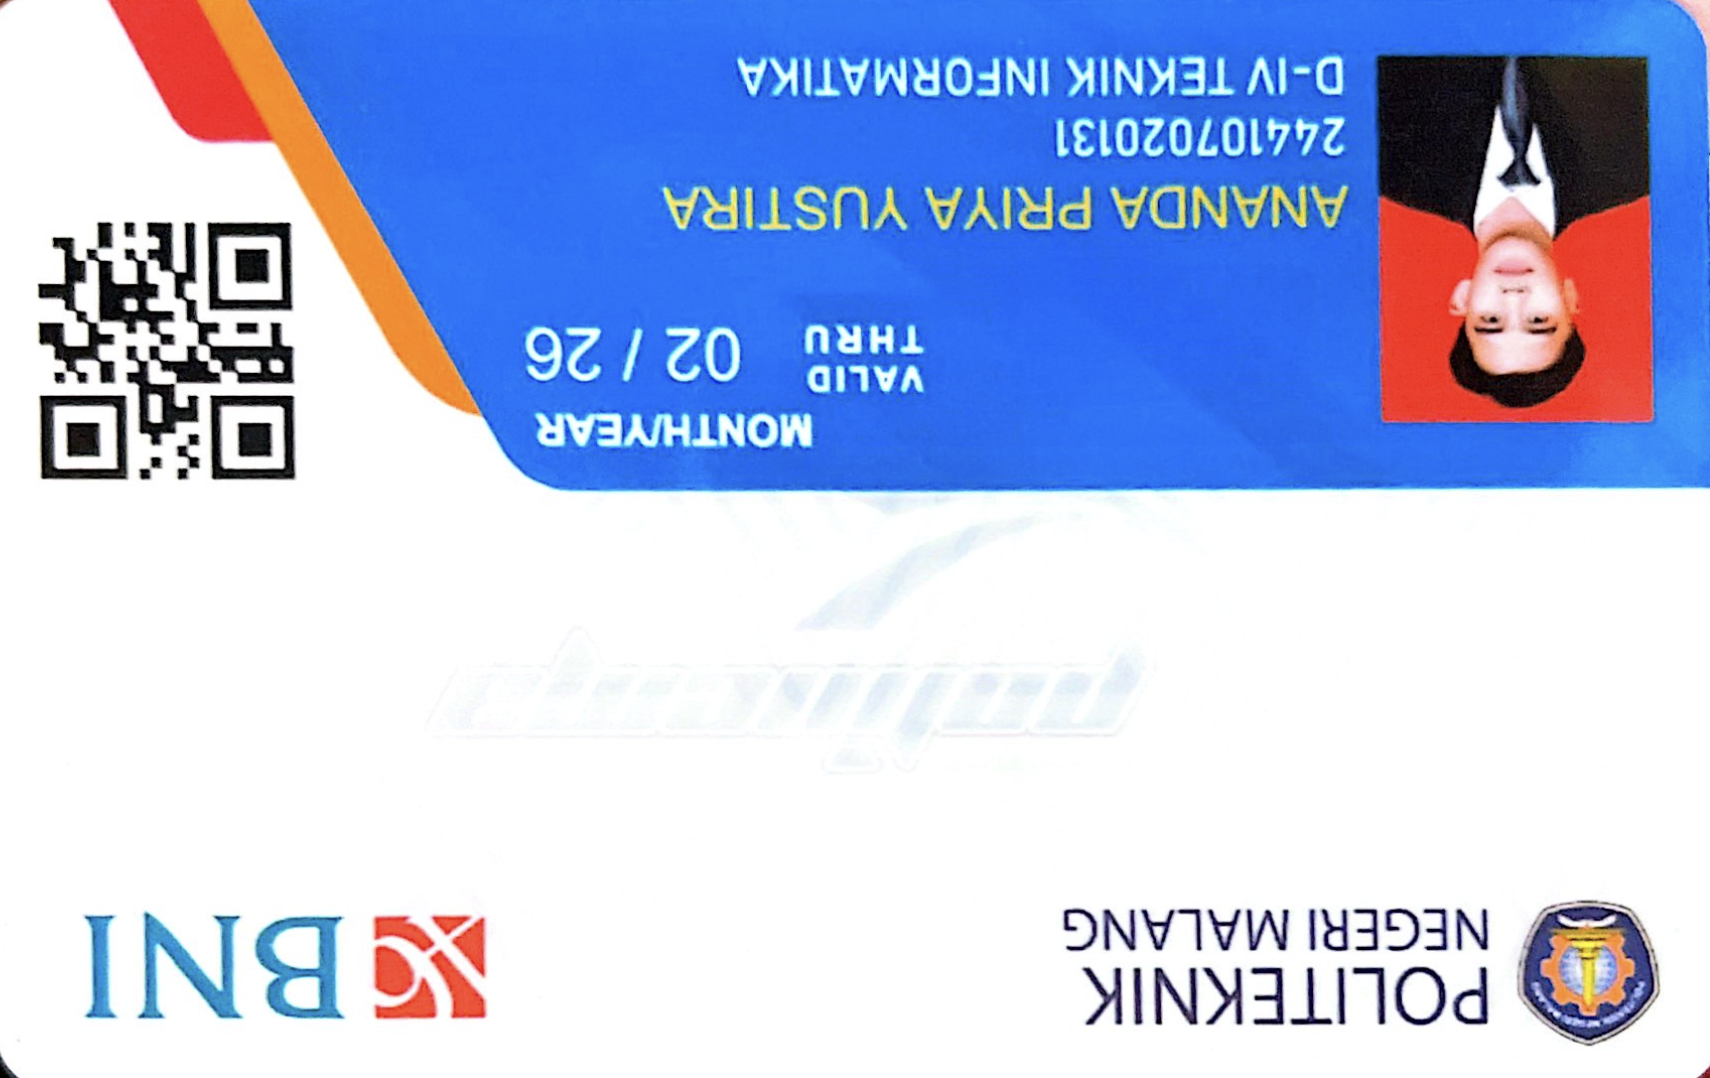

In [16]:

# Flip vertikal dan horizontal (flipCode = -1)
img_flipped = cv2.flip(image, -1)

cv2_imshow(img_flipped)

7. Buat rectangle dan circle pada bagian wajah dari image foto anda saat beraktifitas

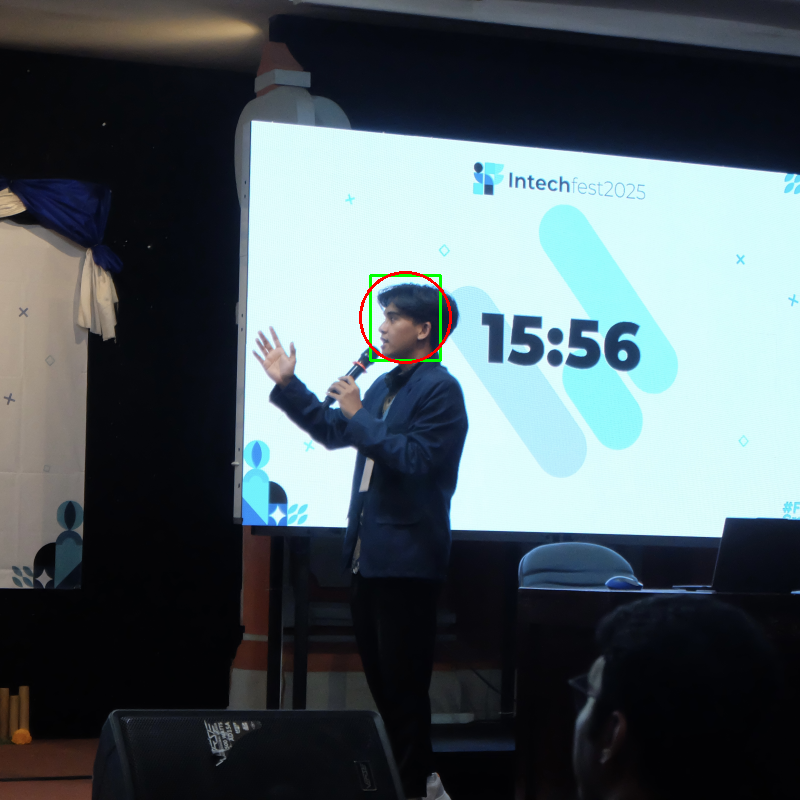

In [17]:

# Baca gambar dan resize ke ukuran fixed (800x800)

img_activity = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/DSCF9661.jpg')
fixed_width, fixed_height = 800, 800
img_activity_resized = cv2.resize(
    img_activity, (fixed_width, fixed_height), interpolation=cv2.INTER_AREA
)

# Koordinat bounding box area wajah pada gambar 800x800
# (x1, y1) = sudut kiri atas wajah, (x2, y2) = sudut kanan bawah wajah
x1, y1 = 370, 275
x2, y2 = 440, 360

# Hitung titik pusat dan radius lingkaran wajah
center_x = (x1 + x2) // 2
center_y = (y1 + y2) // 2
radius = 45

# Buat rectangle (hijau) dan circle (merah)
cv2.rectangle(img_activity_resized, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.circle(img_activity_resized, (center_x, center_y), radius, (0, 0, 255), 2)

# Tampilkan hasil akhir
cv2_imshow(img_activity_resized)

 8. Buat rectangle pada sudut bawah kiri channel B pada color space RGB (citra kitten)

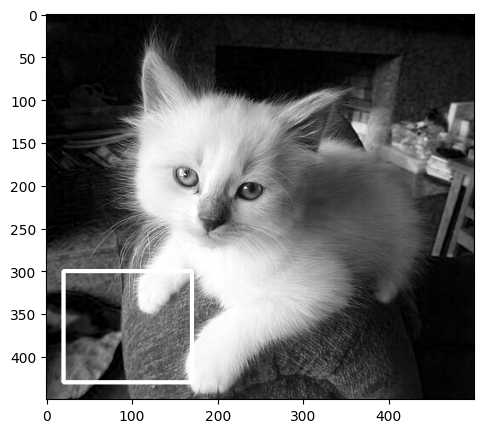

In [18]:
image_kitten = io.imread("/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/Juvenile_Ragdoll.jpg")  # Membaca dalam format RGB


# Ambil Channel B (index 2 dalam format RGB)
img_b_channel = image_kitten[:, :, 2].copy()
kh, kw = img_b_channel.shape

# Koordinat rectangle di sudut bawah kiri
x1, y1 = 20, kh - 150
x2, y2 = 170, kh - 20

# Gambar rectangle berwarna putih (nilai 255 pada citra grayscale)
cv2.rectangle(img_b_channel, (x1, y1), (x2, y2), 255, 4)

fig = plt.figure(figsize=(10, 5))
plt.imshow(img_b_channel, cmap="gray")
plt.show()

9. Lengkapi tulisan nama file pada file citra dari soal no.8. gunakan font,
ukuran font, dan warna font yang sesuai keinginan anda.

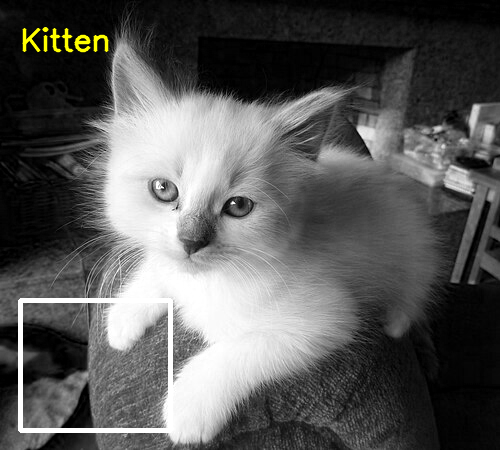

In [19]:
img_kitten_text = cv2.cvtColor(img_b_channel, cv2.COLOR_GRAY2BGR)

filename_text = "Kitten "
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 255)  # Kuning
thickness = 2

cv2.putText(
    img_kitten_text,
    filename_text,
    (20, 50),
    font,
    font_scale,
    font_color,
    thickness,
    cv2.LINE_AA,
)

cv2_imshow(img_kitten_text)

**Tugas Praktikum Group**

Bentuk kelompok masing-masing terdiri dari 2-3 orang. tiap kelompok lakukan
langkah berikut:
1. Akses file image lokal (KTM) dan tampilkan menggunakan OpenCV dan
Matplotlib
2. Tutup tiap bagian tertentu dari KTM tersebut menggunakan fungsi yang telah
Anda pelajari. Kreasikan terkait dengan warna dan ukuran dari bentuk-
bentuknya. </br>
• Kelompok 4 tulisan Malang, POLINEMA dan Barcode



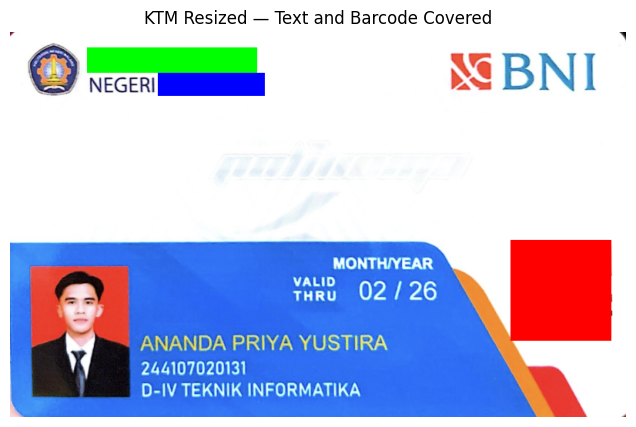

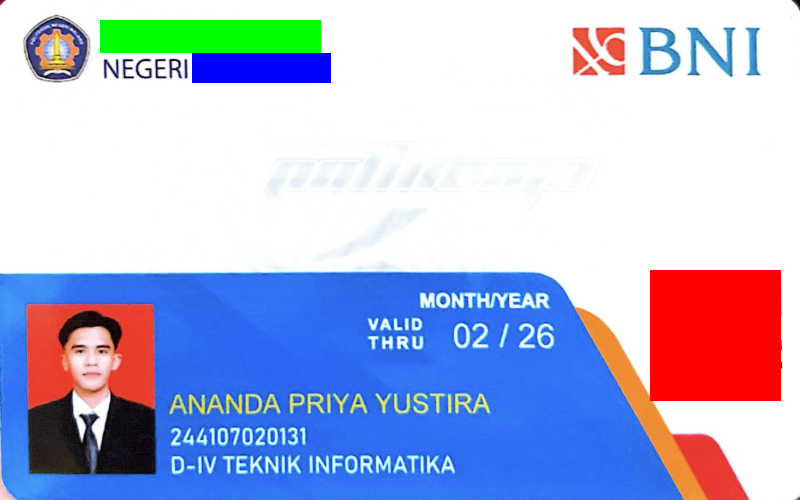

In [25]:

image_ktm = cv2.imread(
    '/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png'
)

# Mengatur ukuran gambar menjadi 800 × 500 px
fixed_width, fixed_height = 800, 500
image_resized = cv2.resize(
    image_ktm,
    (fixed_width, fixed_height),
    interpolation=cv2.INTER_AREA
)

# Warna merah dalam format BGR
red = (0, 0, 255)

# Menutupi kata POLITEKNIK dengan warna hijau
cv2.rectangle(
    image_resized,
    (100, 20),   # Sudut kiri atas
    (320, 52),   # Sudut kanan bawah
    (0, 255, 0), # Green dalam BGR
    thickness=-1
)

# Menutupi kata MALANG dengan warna biru
cv2.rectangle(
    image_resized,
    (192, 53),    # 182 + 10
    (330, 82),    # 320 + 10
    (255, 0, 0),  # Blue dalam BGR
    thickness=-1
)
# Menutupi barcode dengan warna merah
cv2.rectangle(
    image_resized,
    (650, 270),
    (780, 400),
    (0, 0, 255),
    thickness=-1
)

# Konversi BGR ke RGB untuk Matplotlib
image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

# Tampilkan dengan Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(image_rgb)
plt.title("KTM Resized — Text and Barcode Covered")
plt.axis("off")
plt.show()

# Tampilkan dengan OpenCV di Google Colab
cv2_imshow(image_resized)